In [17]:
%matplotlib inline
import lightkurve as lk
import matplotlib.pyplot as plt

In [62]:
search_result = lk.search_lightcurve("MWC 758", auth)
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 71,2023,SPOC,120,73816033,0.0
1,TESS Sector 43,2021,TESS-SPOC,600,73816033,0.0
2,TESS Sector 44,2021,TESS-SPOC,600,73816033,0.0
3,TESS Sector 45,2021,TESS-SPOC,600,73816033,0.0
4,TESS Sector 71,2023,TESS-SPOC,200,73816033,0.0
5,TESS Sector 43,2021,QLP,600,73816033,0.0
6,TESS Sector 44,2021,QLP,600,73816033,0.0
7,TESS Sector 45,2021,QLP,600,73816033,0.0
8,TESS Sector 71,2023,QLP,200,73816033,0.0


## First Lightcurve

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

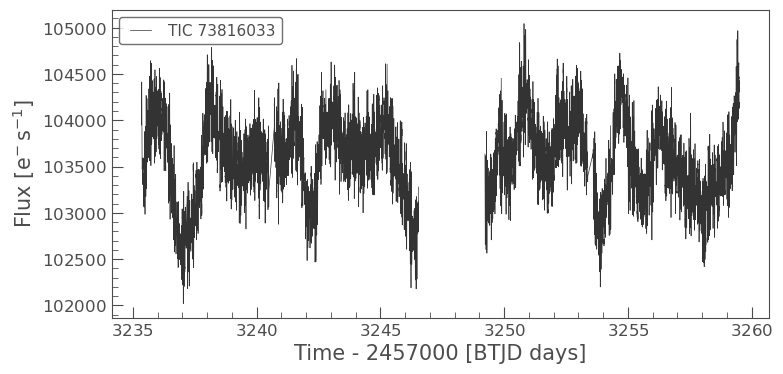

In [7]:
lc = search_result[0].download()
lc.plot()

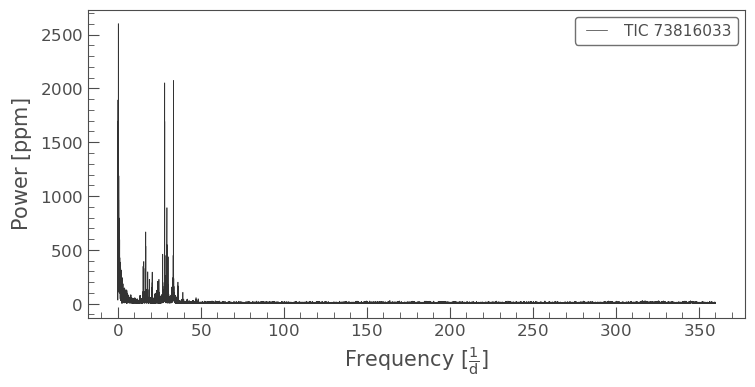

In [28]:
pg = lc.normalize(unit='ppm').to_periodogram()
pg.plot();

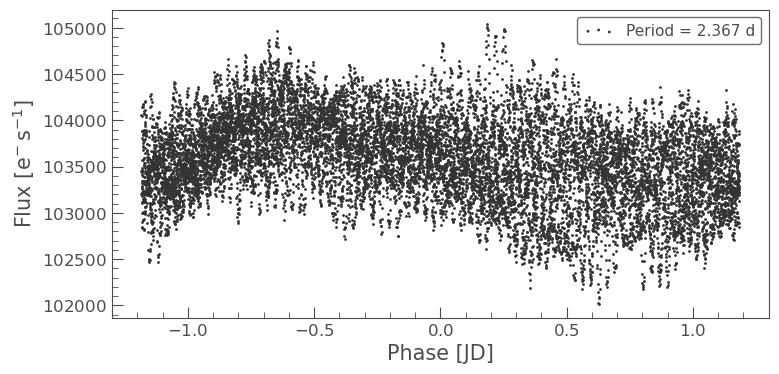

In [29]:
period = pg.period_at_max_power
lc.fold(period).scatter(label=f'Period = {period.value:.3f} d');

## Non-TESS_YSO Lightcurves

In [70]:
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 71,2023,SPOC,120,73816033,0.0
1,TESS Sector 43,2021,TESS-SPOC,600,73816033,0.0
2,TESS Sector 44,2021,TESS-SPOC,600,73816033,0.0
3,TESS Sector 45,2021,TESS-SPOC,600,73816033,0.0
4,TESS Sector 71,2023,TESS-SPOC,200,73816033,0.0
5,TESS Sector 43,2021,QLP,600,73816033,0.0
6,TESS Sector 44,2021,QLP,600,73816033,0.0
7,TESS Sector 45,2021,QLP,600,73816033,0.0
8,TESS Sector 71,2023,QLP,200,73816033,0.0


In [67]:
sr = search_result[search_result.table["author"] != "TESS-YSO"]
lc_collection = sr.download_all(quality_bitmask='hardest')

TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]

TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]

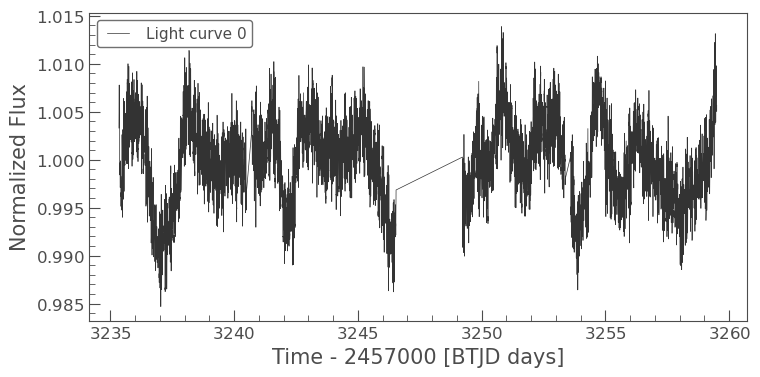

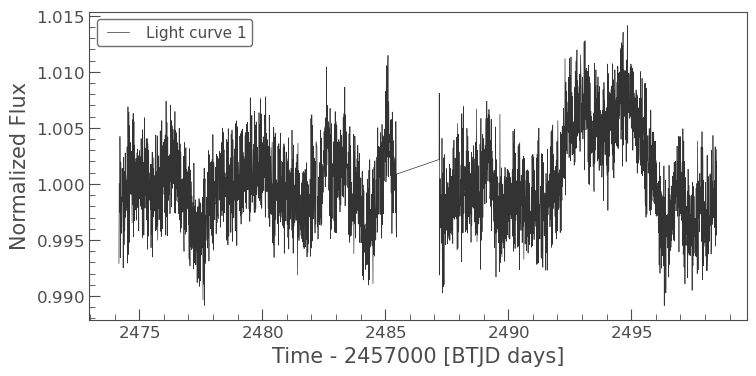

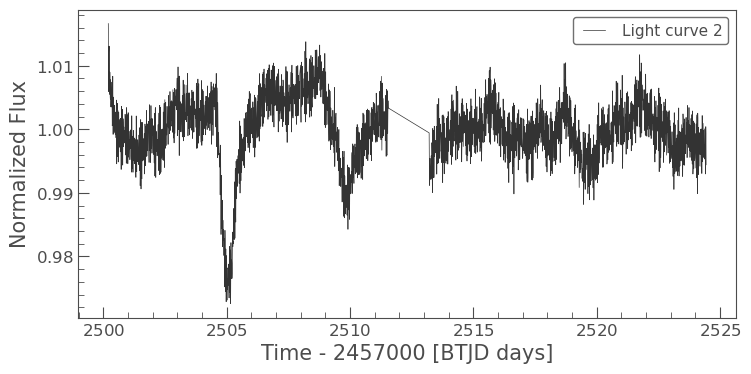

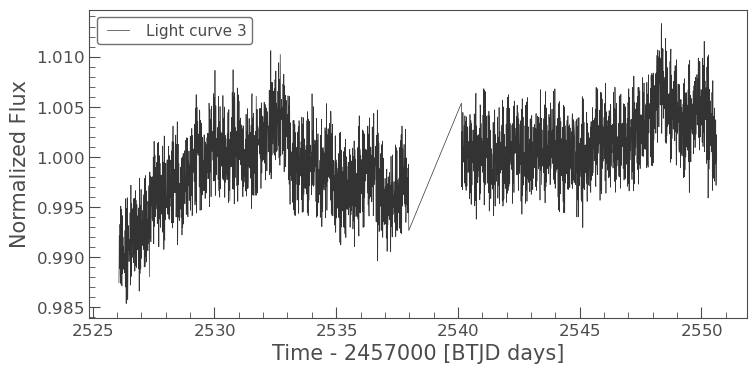

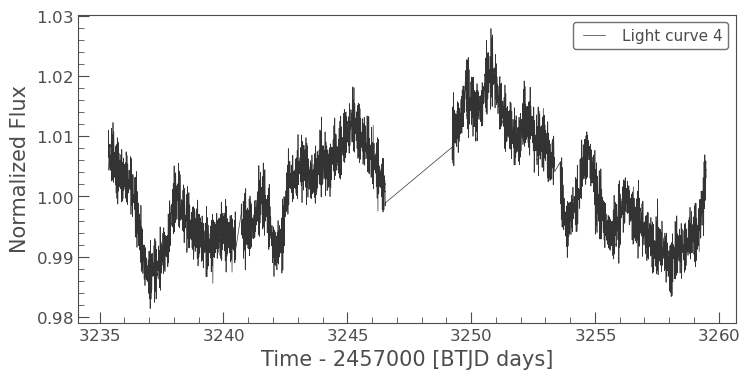

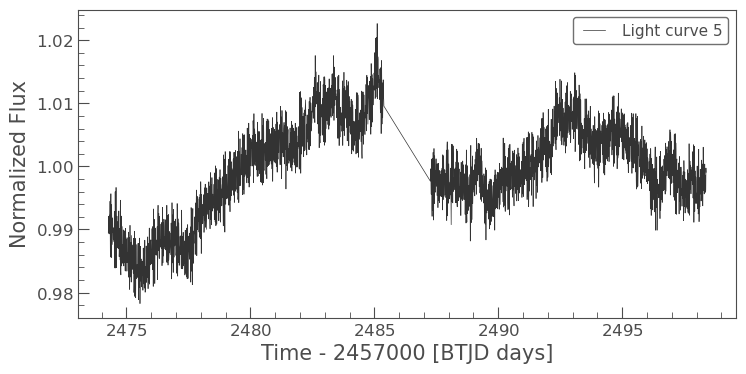

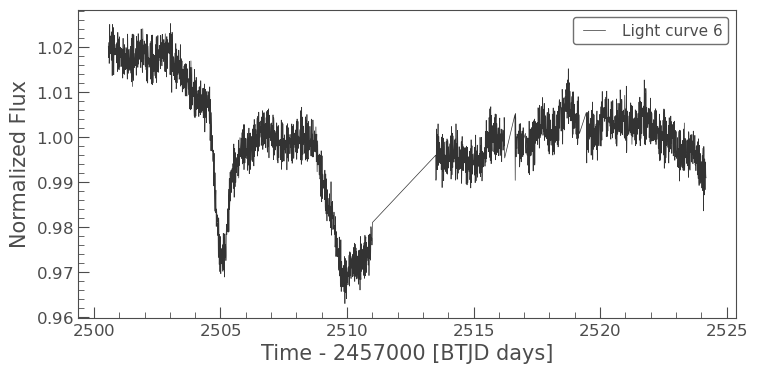

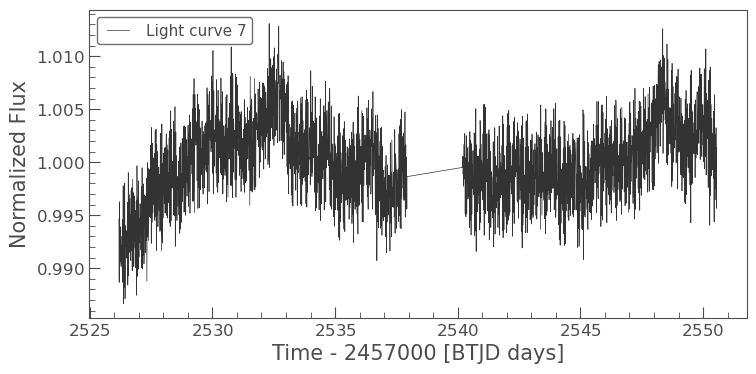

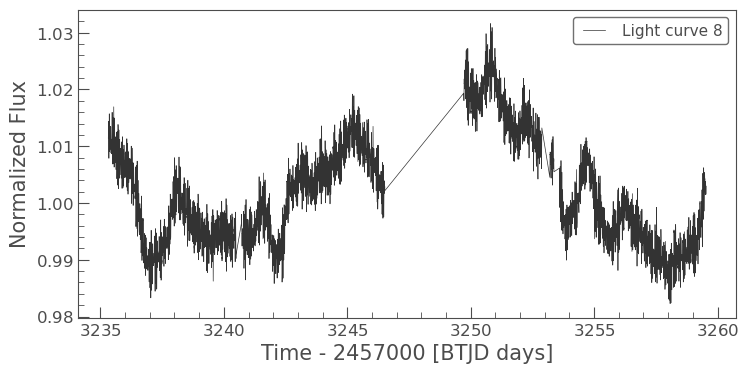

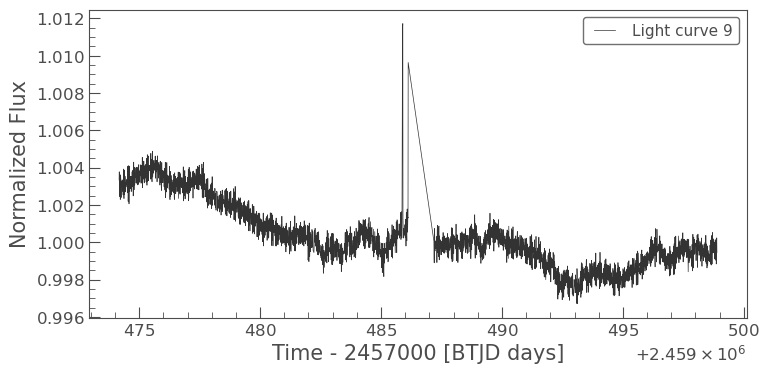

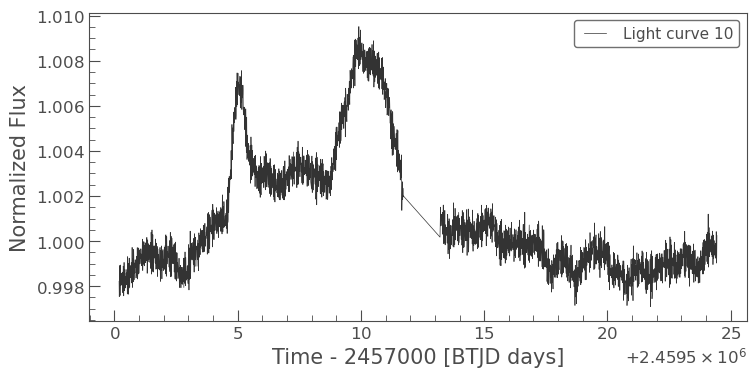

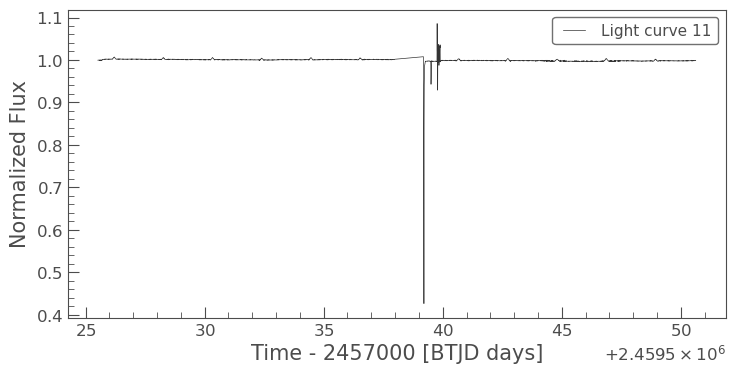

In [68]:
for i, lc in enumerate(lc_collection):
    ax =lc.remove_nans().normalize().plot(label=f"Light curve {i}")
    # ax.set_xlim(30,40)

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

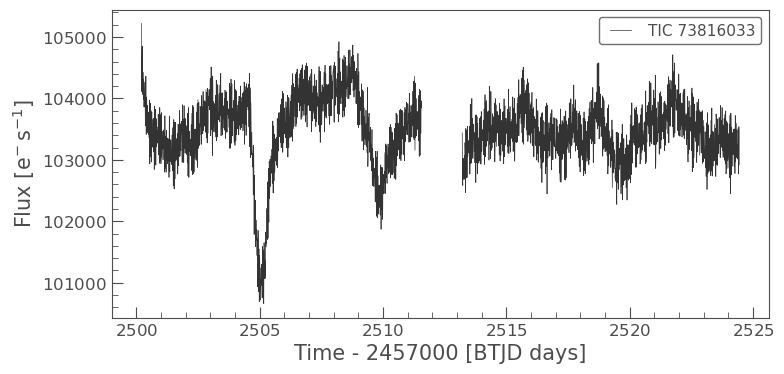

In [20]:
sr0 = sr[2].download()
sr0.plot()

/Users/shanekomeiji/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/shanekomeiji/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astropy.table.table]
TypeError('The value must be a valid Python or Numpy numeric type.') [astro

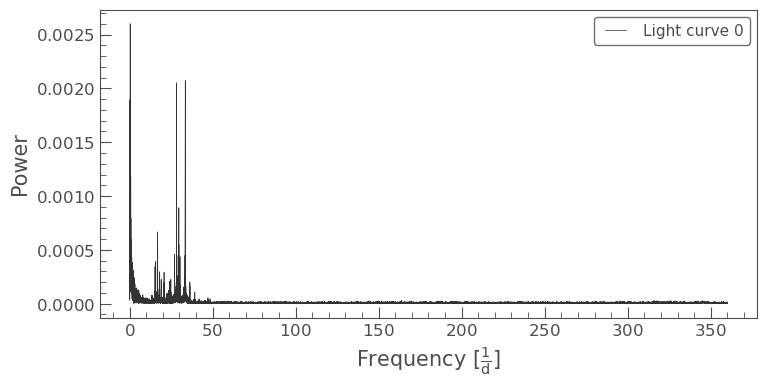

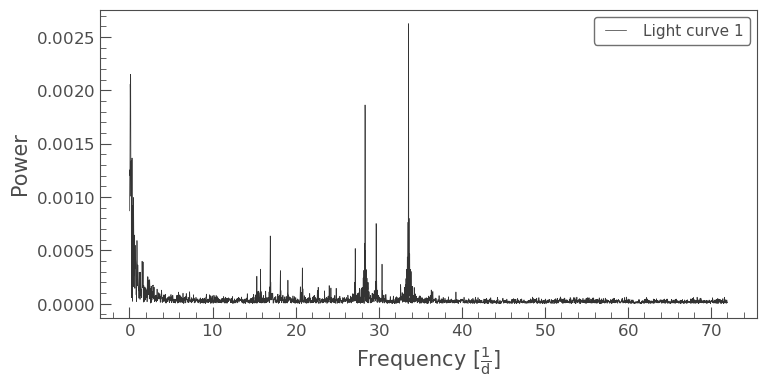

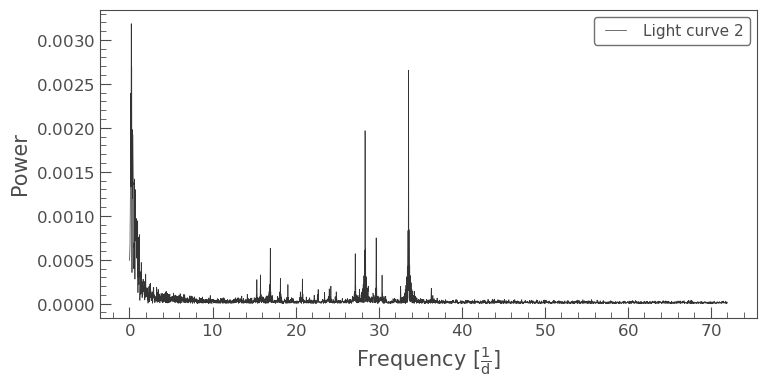

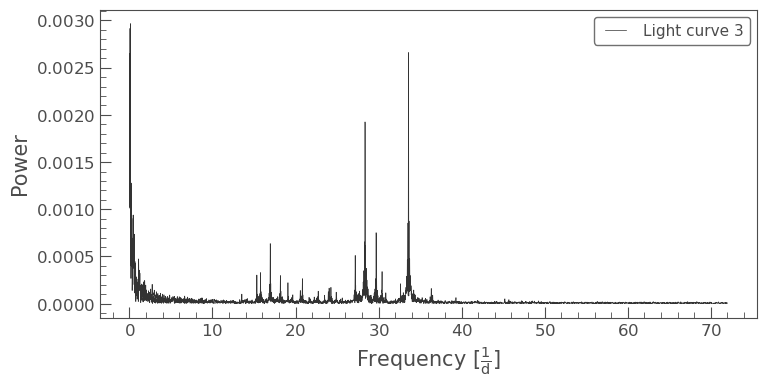

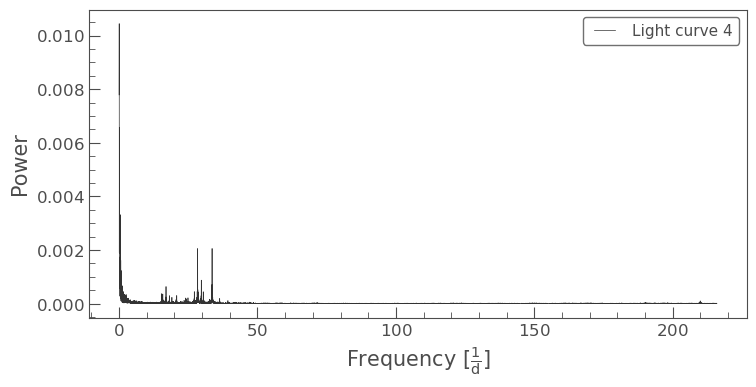

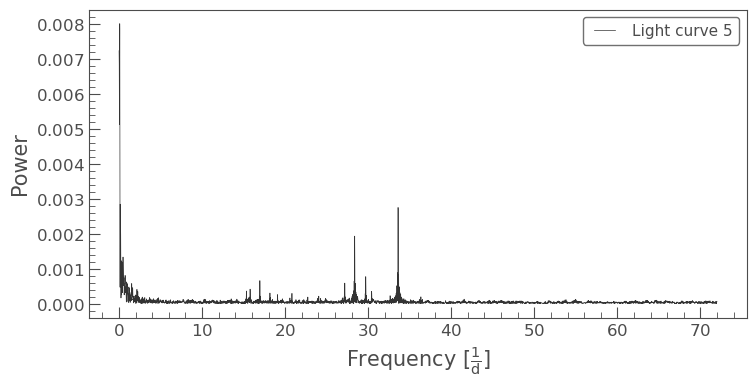

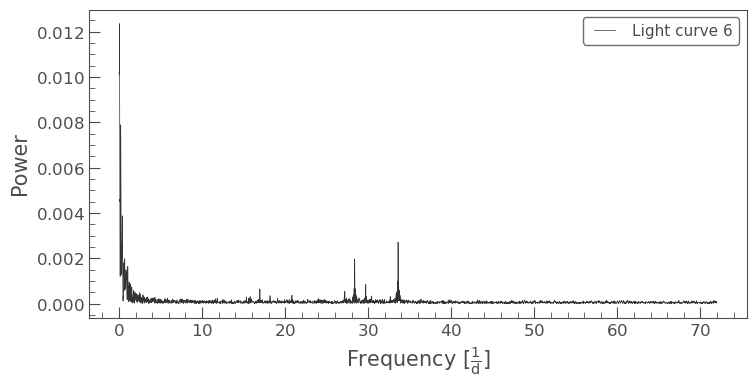

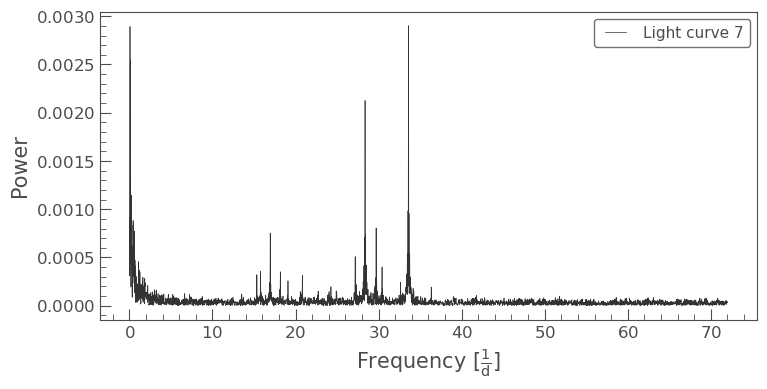

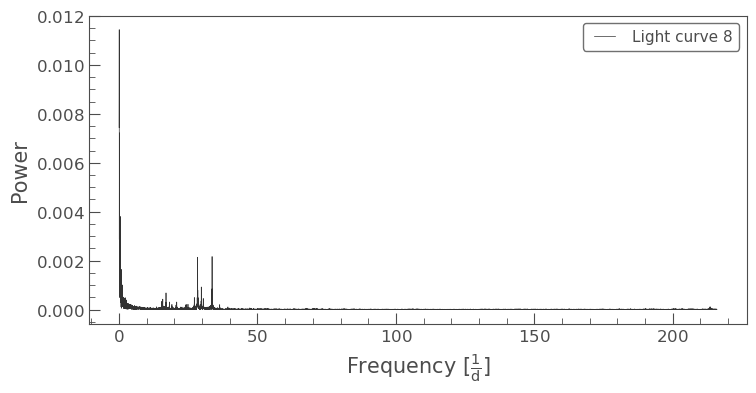

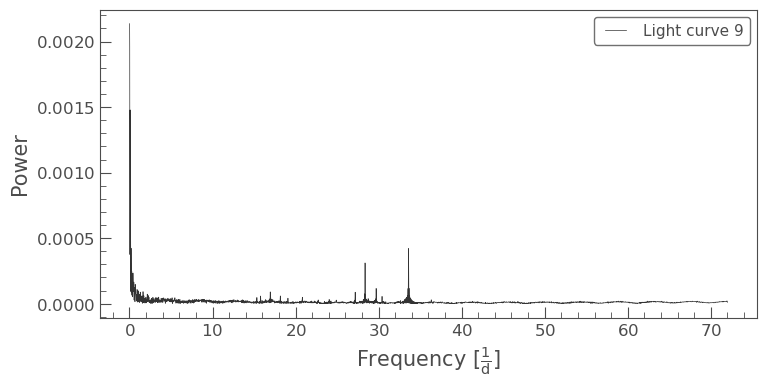

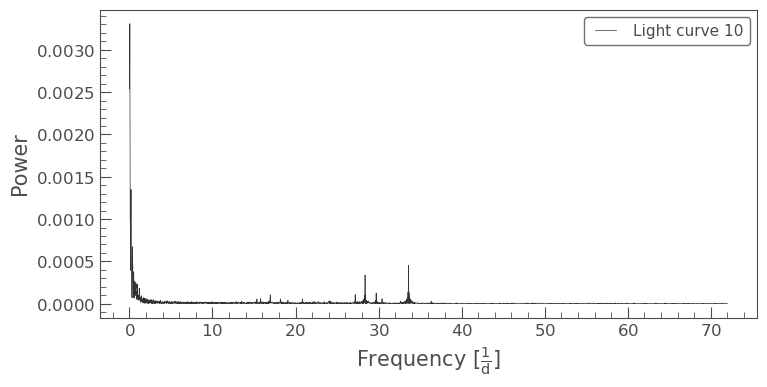

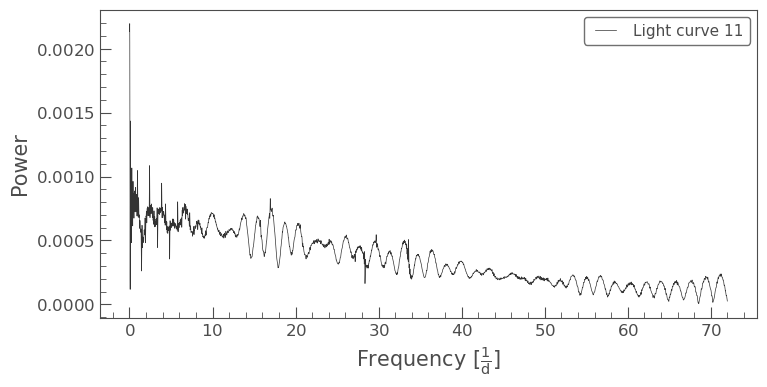

In [69]:
periodograms = []

for i, lc in enumerate(lc_collection):
    lc_norm = lc.normalize()
    pg = lc_norm.to_periodogram()
    periodograms.append(pg)

    pg.plot(label=f"Light curve {i}")

# TESS-YSO

In [39]:
yso = search_result[search_result.table["author"] == "TESS-YSO"]
yso

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 43,2021,TESS-YSO,600,73816033,0.0
1,TESS Sector 44,2021,TESS-YSO,600,73816033,0.0
2,TESS Sector 45,2021,TESS-YSO,600,73816033,0.0


In [47]:
yso_lcc = lk.LightCurveCollection(lc_yso_list)

Plotting 0 length: 3408
Plotting 1 length: 3278
Plotting 2 length: 3450


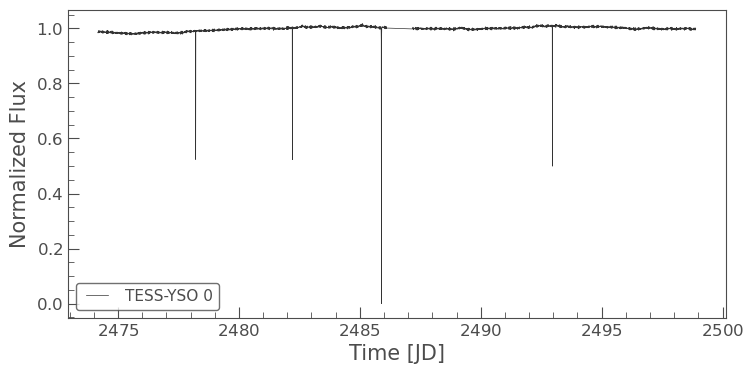

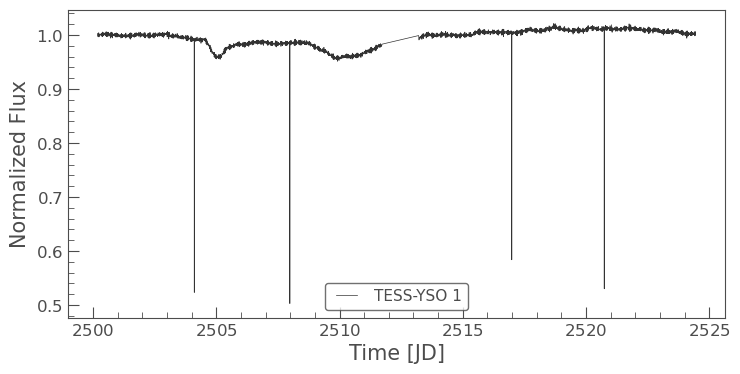

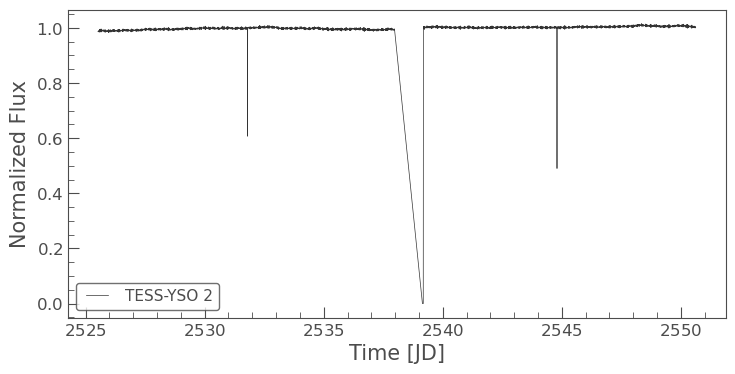

In [57]:
for i, lc in enumerate(yso_lcc):
    print("Plotting", i, "length:", len(lc))
    lc.normalize().plot(label=f"TESS-YSO {i}")

Light curve 0: max period = 123.5880126500001 d
Light curve 1: max period = 24.24491781000006 d
Light curve 2: max period = 15.695156700000156 d


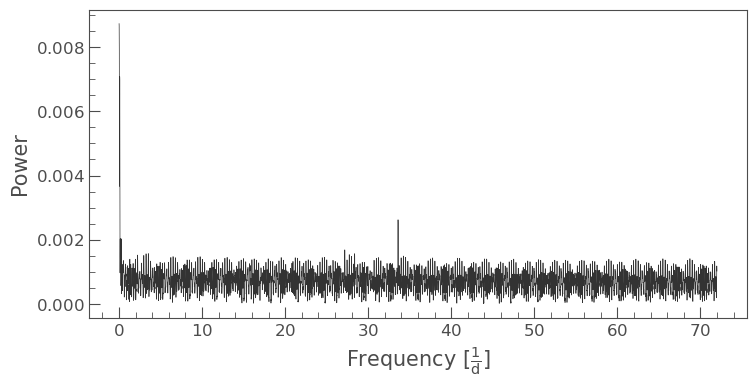

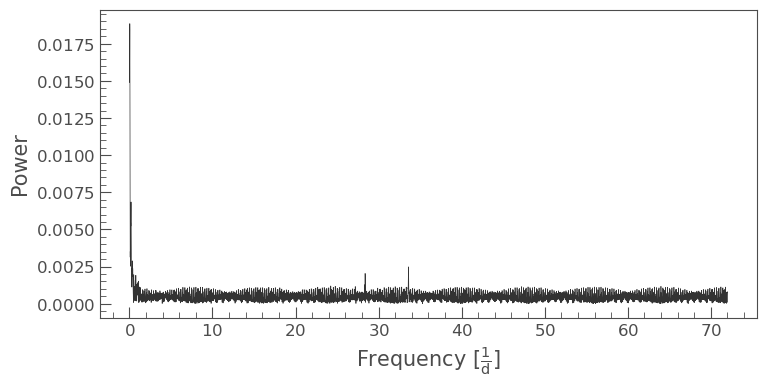

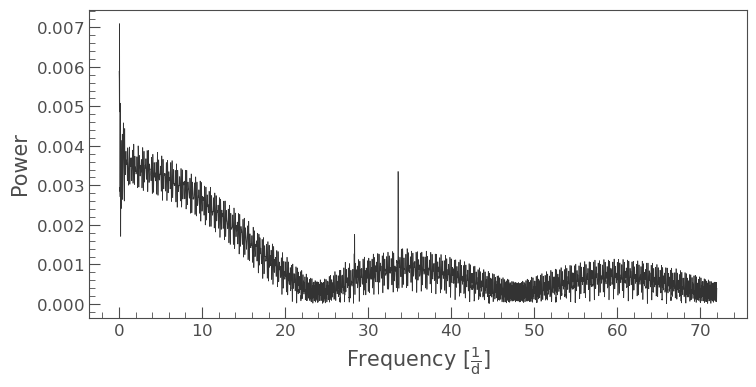

In [60]:
periodograms = []

for i, lc in enumerate(yso_lcc):
    lc_norm = lc.remove_nans().normalize()

    pg = lc_norm.to_periodogram()

    periodograms.append(pg)

    print(f"Light curve {i}: max period =", pg.period_at_max_power)
    pg.plot()

In [44]:
%matplotlib inline
import importlib
import lightkurve_utils as utils

importlib.reload(utils)

<module 'lightkurve_utils' from '/Users/shanekomeiji/Desktop/student_download/lightkurve_utils.py'>

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 71 2023   SPOC     120    73816033      0.0


/Users/shanekomeiji/Desktop/student_download/lightkurve_utils.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
/Users/shanekomeiji/Desktop/student_download/lightkurve_utils.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


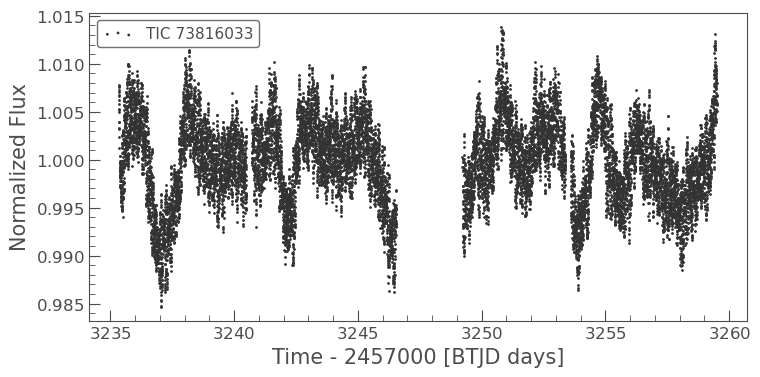

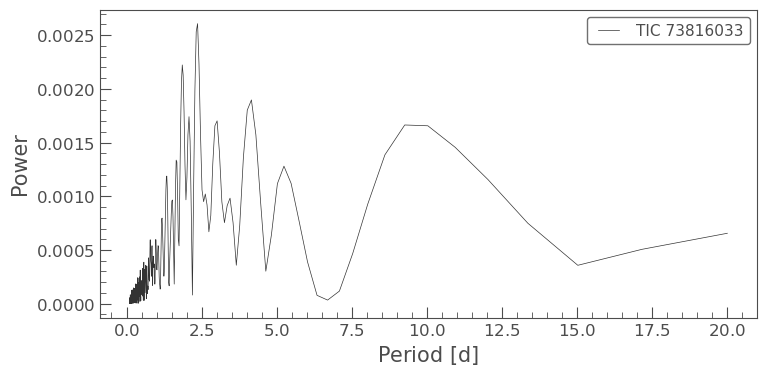

In [41]:
lc, pg = utils.plot_lightcurve_periodogram(
    "MWC 758",
    author="SPOC"
)

In [43]:
import astropy.units as u

pg = lc.to_periodogram(
    minimum_frequency=0.05 / u.day,
    maximum_frequency=50 / u.day
)

print(pg.frequency.min())
print(pg.frequency.max())

0.05 1 / d
49.99292536239602 1 / d


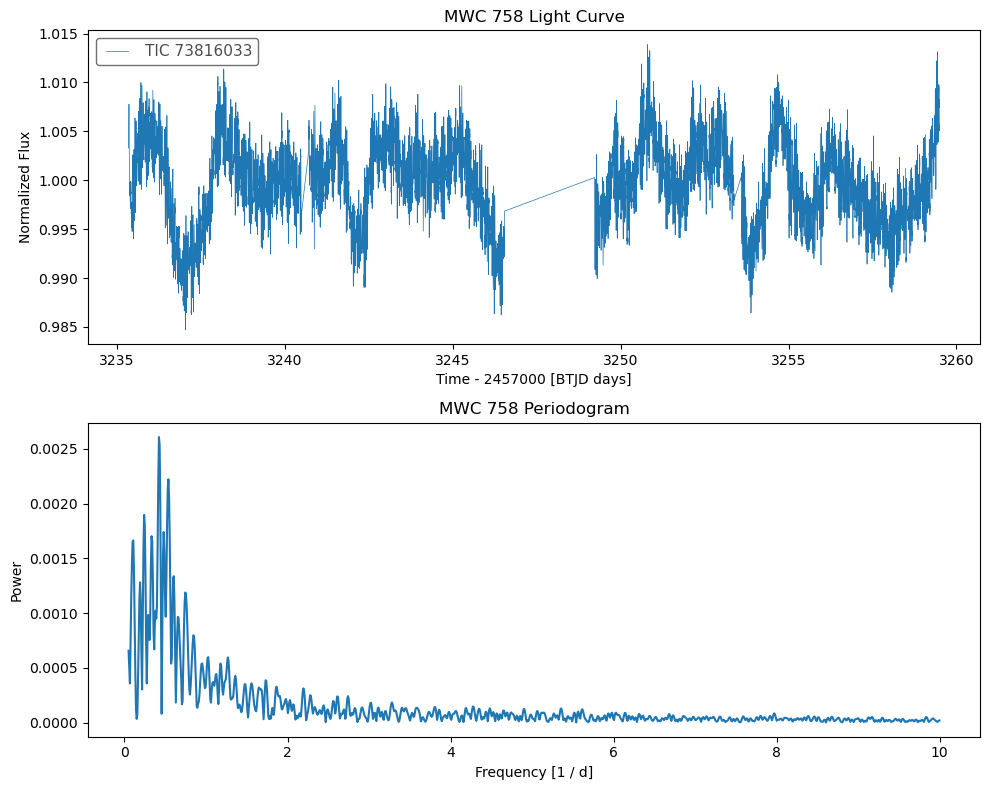

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Light curve
lc.plot(ax=axes[0])
axes[0].set_title("MWC 758 Light Curve")

# Periodogram in frequency space
axes[1].plot(pg.frequency.value, pg.power.value)
axes[1].set_xlabel(f"Frequency [{pg.frequency.unit}]")
axes[1].set_ylabel("Power")
axes[1].set_title("MWC 758 Periodogram")

plt.tight_layout()

# Save the entire figure
plt.savefig("MWC758_summary.png", dpi=300, bbox_inches="tight")

plt.show()

## DM Tau

In [48]:
import lightkurve as lk
search_result = lk.search_lightcurve("DM Tau")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,K2 Campaign 13,2017,K2,1800,ktwo247047380,0.0
1,TESS Sector 43,2021,SPOC,120,61259576,0.0
2,TESS Sector 44,2021,SPOC,120,61259576,0.0
3,TESS Sector 70,2023,SPOC,120,61259576,0.0
4,TESS Sector 71,2023,SPOC,120,61259576,0.0
5,TESS Sector 43,2021,TESS-SPOC,600,61259576,0.0
6,TESS Sector 44,2021,TESS-SPOC,600,61259576,0.0
7,TESS Sector 70,2023,TESS-SPOC,200,61259576,0.0
8,TESS Sector 71,2023,TESS-SPOC,200,61259576,0.0


SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 43 2021   SPOC     120    61259576      0.0


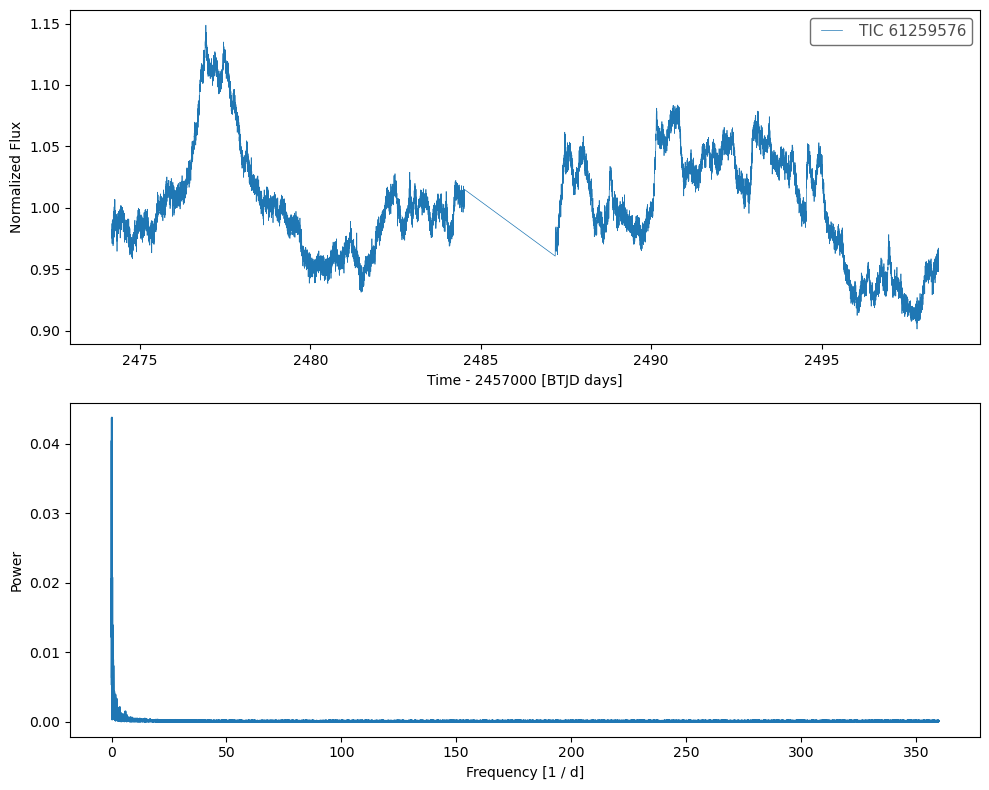

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 44 2021   SPOC     120    61259576      0.0


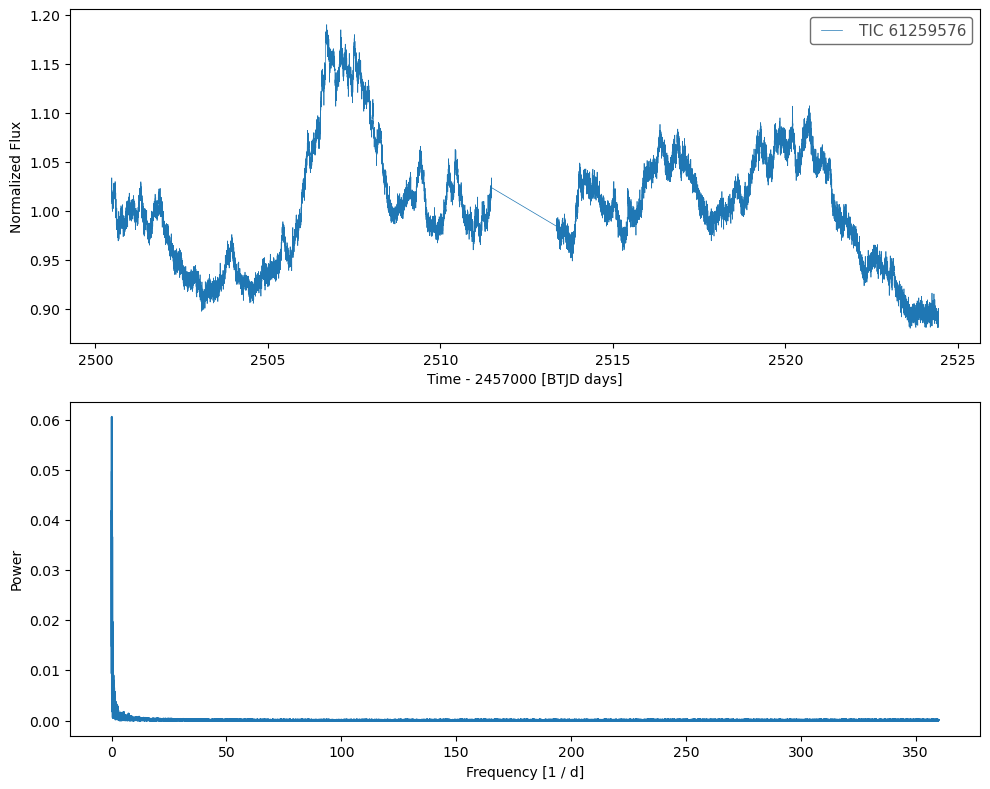

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 70 2023   SPOC     120    61259576      0.0


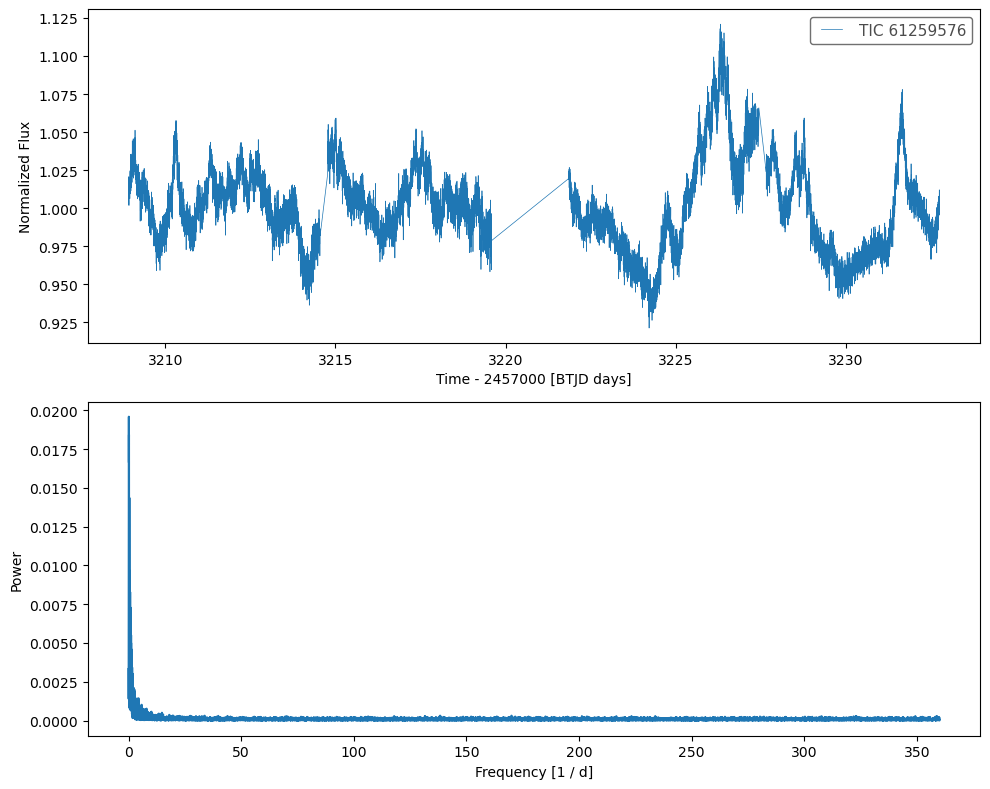

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 71 2023   SPOC     120    61259576      0.0


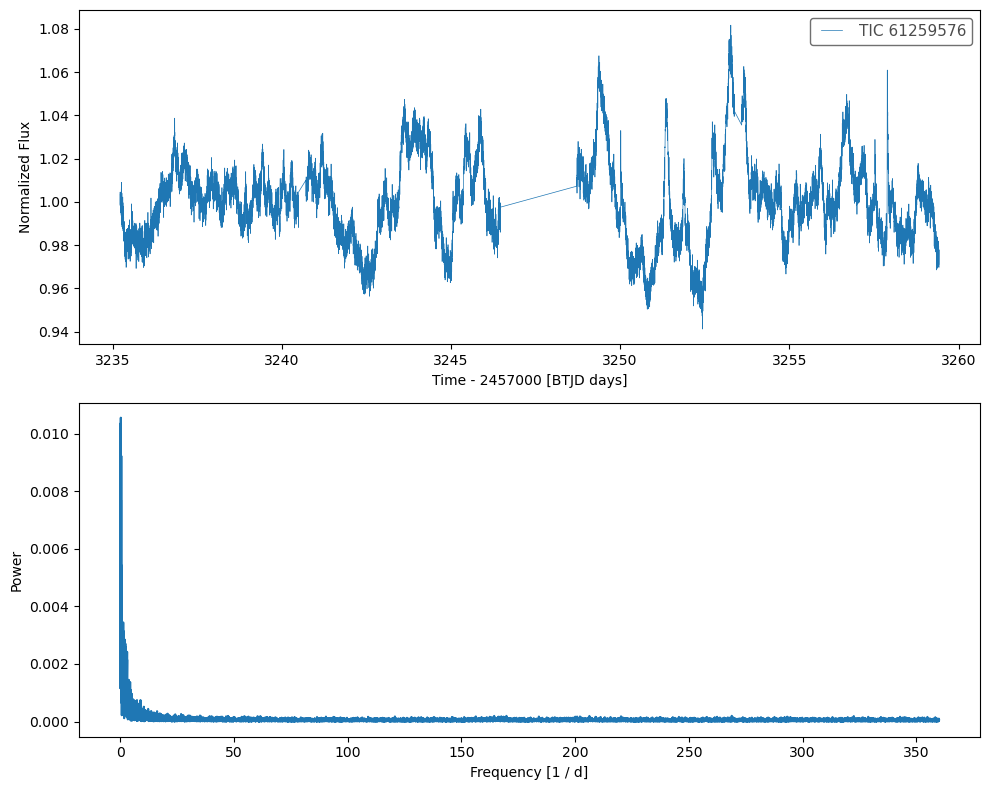

In [49]:
sectors = [43, 44, 70,71]

for i in range(len(sectors)):
    lc, pg = utils.get_lightcurve_periodogram(
    "DM Tau",
    author="SPOC",
    sector=sectors[i]
    )

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Light curve
    lc.plot(ax=axes[0])

    # Periodogram in frequency space
    axes[1].plot(pg.frequency.value, pg.power.value)
    axes[1].set_xlabel(f"Frequency [{pg.frequency.unit}]")
    axes[1].set_ylabel("Power")

    plt.tight_layout()

    plt.show()

In [52]:
import lightkurve as lk
search_result = lk.search_lightcurve("AA Tau")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,K2 Campaign 13,2017,K2,1800,ktwo247810494,0.0
1,TESS Sector 43,2021,SPOC,120,268510757,0.0
2,TESS Sector 44,2021,SPOC,120,268510757,0.0
3,TESS Sector 70,2023,SPOC,20,268510757,0.0
4,TESS Sector 71,2023,SPOC,20,268510757,0.0
5,TESS Sector 70,2023,SPOC,120,268510757,0.0
6,TESS Sector 71,2023,SPOC,120,268510757,0.0
7,TESS Sector 43,2021,TESS-SPOC,600,268510757,0.0
8,TESS Sector 44,2021,TESS-SPOC,600,268510757,0.0


SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 43 2021   SPOC     120   268510757      0.0


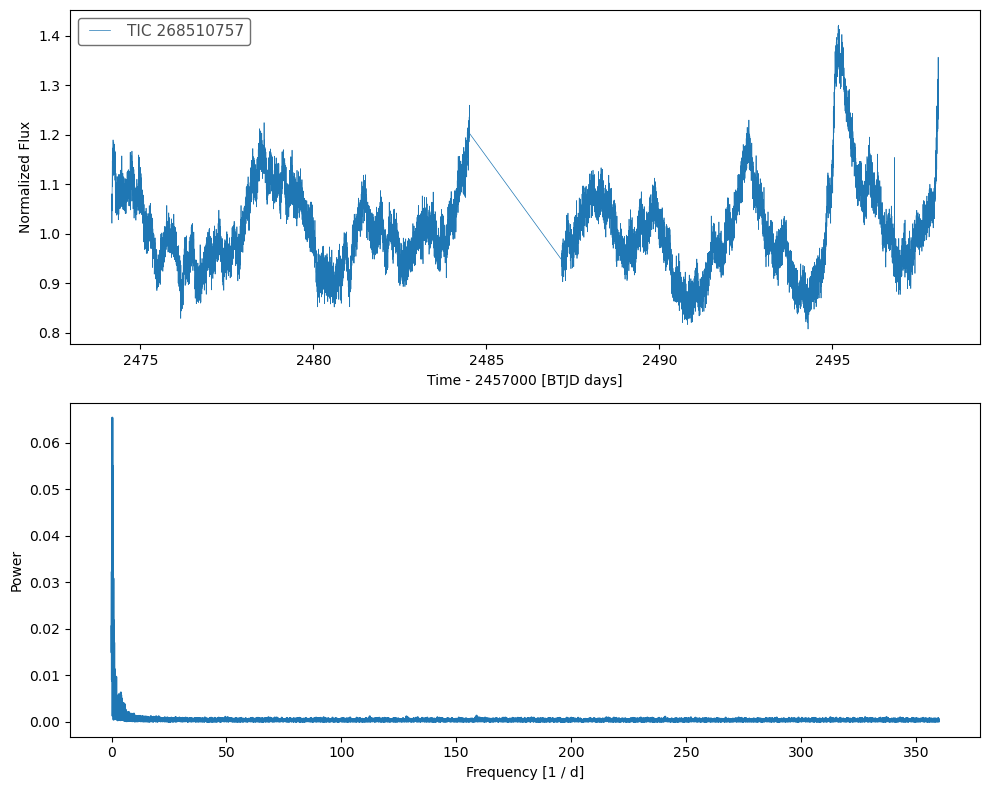

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 44 2021   SPOC     120   268510757      0.0


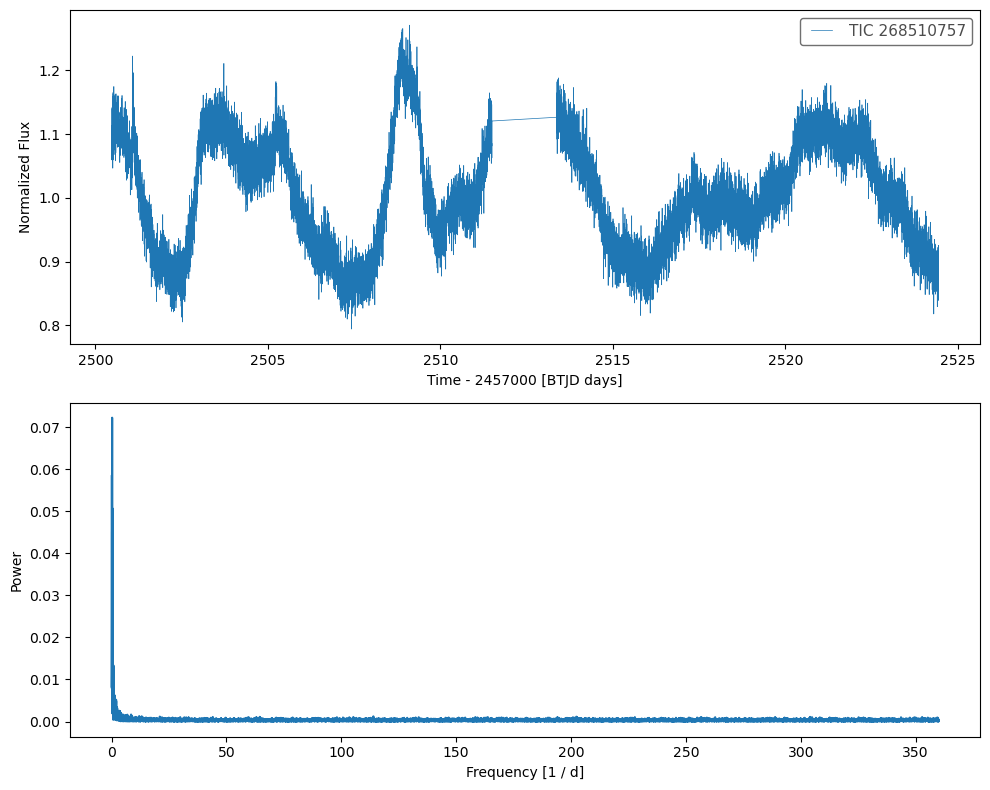

SearchResult containing 2 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 70 2023   SPOC      20   268510757      0.0
  1 TESS Sector 70 2023   SPOC     120   268510757      0.0


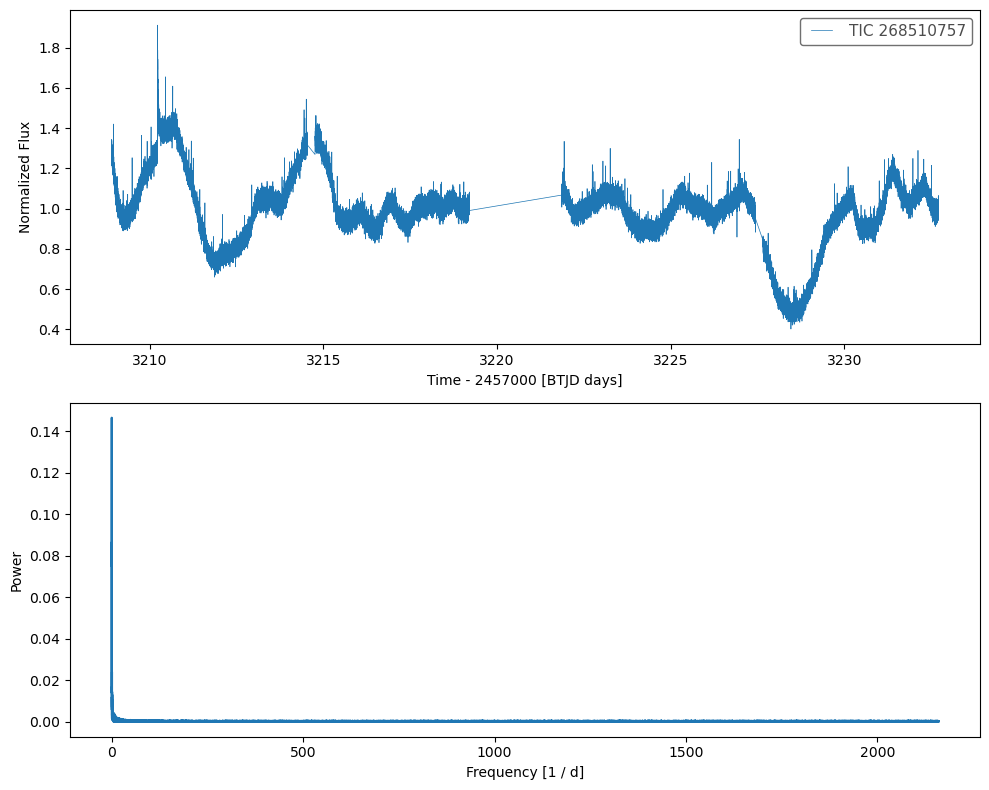

SearchResult containing 2 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 71 2023   SPOC      20   268510757      0.0
  1 TESS Sector 71 2023   SPOC     120   268510757      0.0


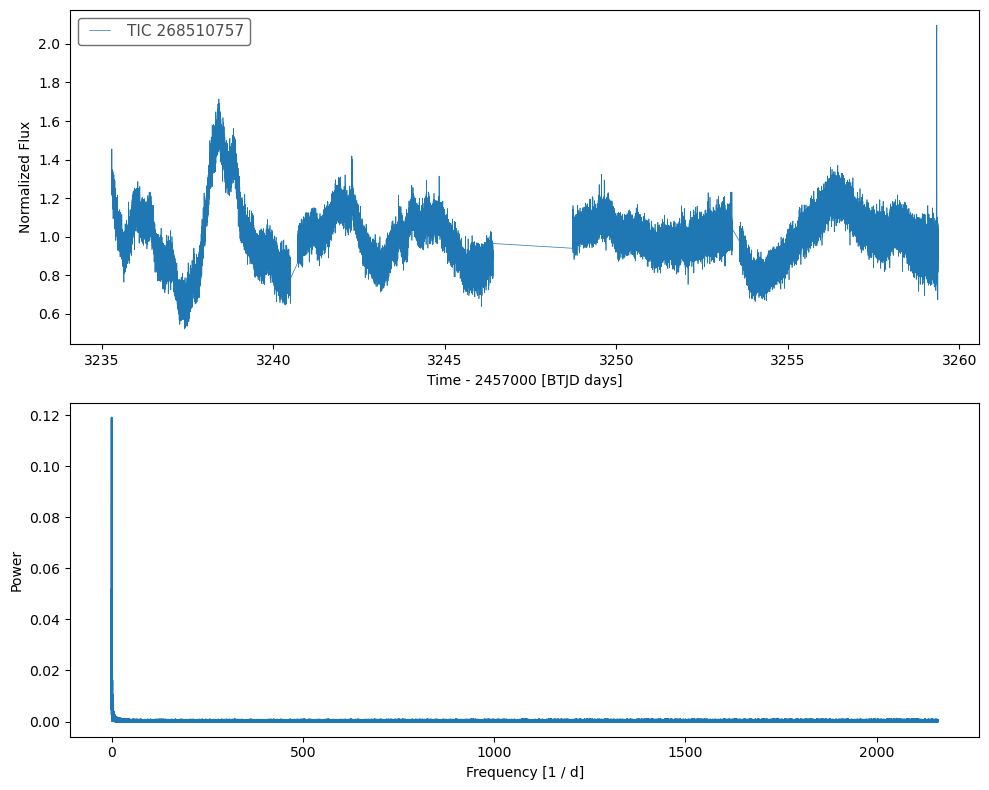

In [51]:
sectors = [43, 44, 70,71]

for i in range(len(sectors)):
    lc, pg = utils.get_lightcurve_periodogram(
    "AA Tau",
    author="SPOC",
    sector=sectors[i]
    )

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Light curve
    lc.plot(ax=axes[0])

    # Periodogram in frequency space
    axes[1].plot(pg.frequency.value, pg.power.value)
    axes[1].set_xlabel(f"Frequency [{pg.frequency.unit}]")
    axes[1].set_ylabel("Power")

    plt.tight_layout()

    plt.show()

In [57]:
import lightkurve as lk
search_result = lk.search_lightcurve("LkCa 15")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,K2 Campaign 13,2017,K2,60,ktwo247520207,0.0
1,K2 Campaign 13,2017,K2,1800,ktwo247520207,0.0
2,TESS Sector 43,2021,SPOC,120,118681038,0.0
3,TESS Sector 44,2021,SPOC,120,118681038,0.0
4,TESS Sector 70,2023,SPOC,120,118681038,0.0
5,TESS Sector 71,2023,SPOC,120,118681038,0.0
6,TESS Sector 43,2021,TESS-SPOC,600,118681038,0.0
7,TESS Sector 44,2021,TESS-SPOC,600,118681038,0.0
8,TESS Sector 70,2023,TESS-SPOC,200,118681038,0.0


SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 43 2021   SPOC     120   118681038      0.0


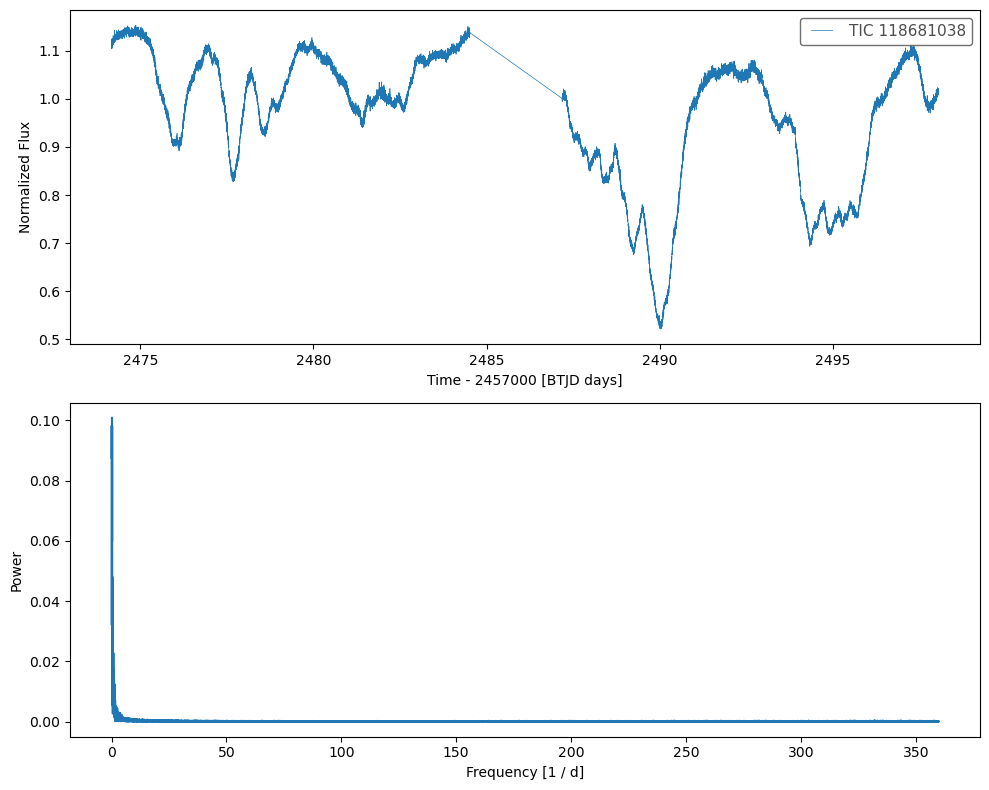

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 44 2021   SPOC     120   118681038      0.0


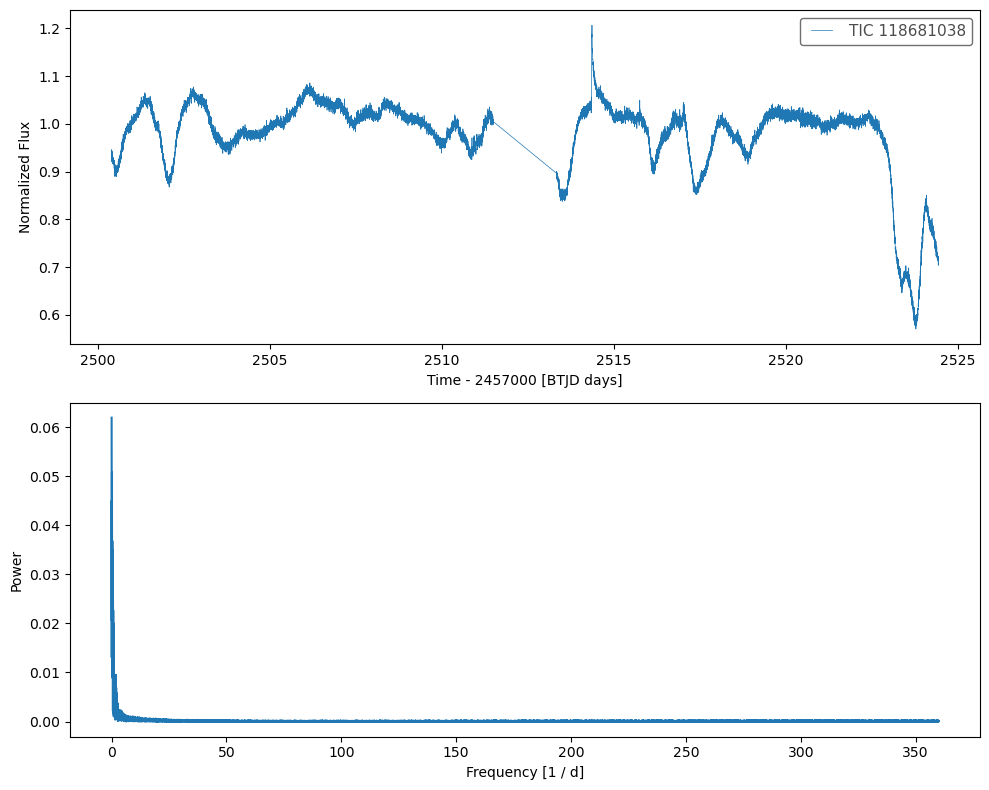

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 70 2023   SPOC     120   118681038      0.0


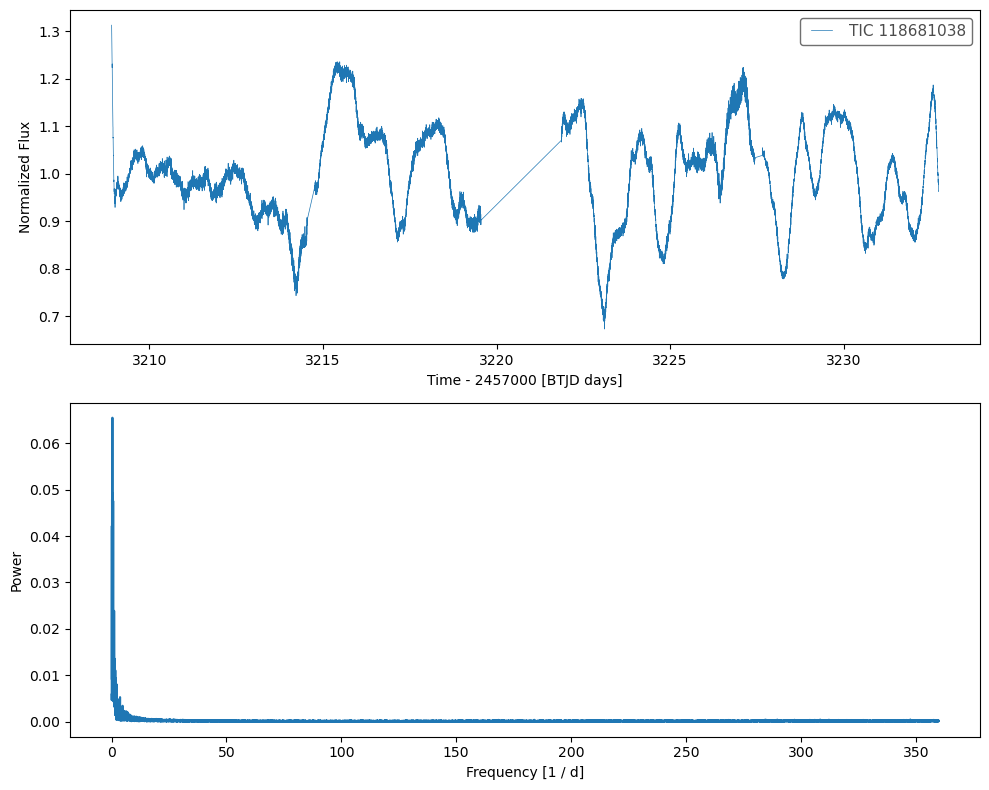

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 71 2023   SPOC     120   118681038      0.0


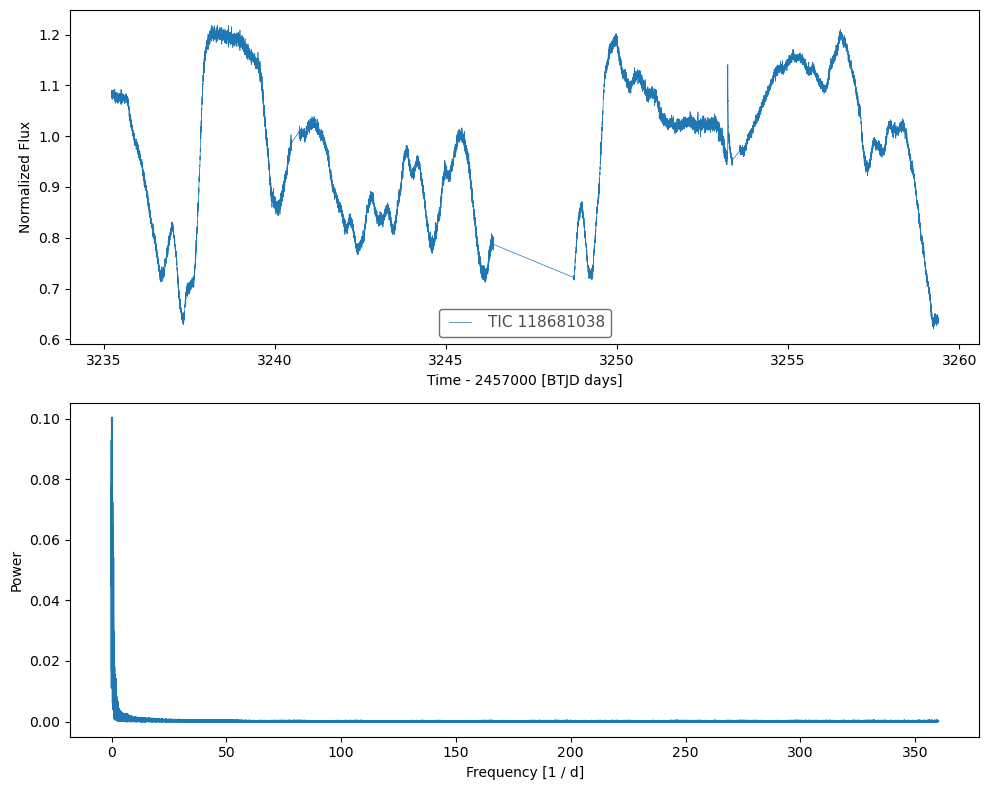

In [60]:
sectors = [43, 44, 70,71]

for i in range(len(sectors)):
    lc, pg = utils.get_lightcurve_periodogram(
    "LkCa 15",
    author="SPOC",
    sector=sectors[i]
    )

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Light curve
    lc.plot(ax=axes[0])

    # Periodogram in frequency space
    axes[1].plot(pg.frequency.value, pg.power.value)
    axes[1].set_xlabel(f"Frequency [{pg.frequency.unit}]")
    axes[1].set_ylabel("Power")

    plt.tight_layout()

    plt.show()